In [1]:
from sklearn.datasets import load_iris
import numpy as np

iris = load_iris()
X = iris.data
y = iris.target

In [2]:
def gini(y):
    classes, counts = np.unique(y, return_counts=True)
    p = counts / counts.sum()
    return 1 - np.sum(p ** 2)

In [3]:
def split_dataset(X, y, feature, threshold):
    left_mask = X[:, feature] < threshold
    right_mask = ~left_mask
    
    return X[left_mask], y[left_mask], X[right_mask], y[right_mask]

In [12]:
def best_split(X, y):
    best_gini = float('inf')
    best_feature = None
    best_threshold = None
    
    n_samples, n_features = X.shape
    
    for feature in range(n_features):
        values = np.sort(np.unique(X[:, feature]))
        thresholds = (values[:-1] + values[1:]) / 2
        
        for t in thresholds:
            X_l, y_l, X_r, y_r = split_dataset(X, y, feature, t)
            
            if len(y_l) == 0 or len(y_r) == 0:
                continue
            
            g = (len(y_l) * gini(y_l) + len(y_r) * gini(y_r)) / len(y)
            
            if g < best_gini:
                best_gini = g
                best_feature = feature
                best_threshold = t
    
    return best_feature, best_threshold, best_gini

In [13]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value  # leaf node

In [14]:
def build_tree(X, y, depth=0, max_depth=3, min_samples=5):
    
    # Stopping criteria
    if len(y) < min_samples or depth >= max_depth or gini(y) == 0:
        leaf_value = np.bincount(y).argmax()
        return Node(value=leaf_value)
    
    feature, threshold, _ = best_split(X, y)
    
    if feature is None:
        leaf_value = np.bincount(y).argmax()
        return Node(value=leaf_value)
    
    X_l, y_l, X_r, y_r = split_dataset(X, y, feature, threshold)
    
    left = build_tree(X_l, y_l, depth+1, max_depth, min_samples)
    right = build_tree(X_r, y_r, depth+1, max_depth, min_samples)
    
    return Node(feature, threshold, left, right)

In [15]:
def predict_one(x, node):
    if node.value is not None:
        return node.value
    
    if x[node.feature] < node.threshold:
        return predict_one(x, node.left)
    else:
        return predict_one(x, node.right)


def predict(X, tree):
    return np.array([predict_one(x, tree) for x in X])

In [16]:
import matplotlib.pyplot as plt

X_vis = X[:, 2:4]  # petal length, width

def plot_data(X, y):
    for i in range(3):
        plt.scatter(X[y==i, 0], X[y==i, 1], label=iris.target_names[i])
    plt.xlabel("Petal Length")
    plt.ylabel("Petal Width")
    plt.legend()

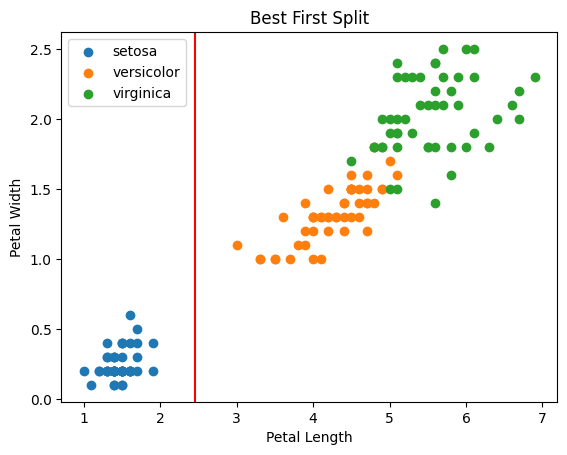

In [17]:
feature, threshold, _ = best_split(X_vis, y)

plot_data(X_vis, y)

if feature == 0:
    plt.axvline(threshold, color='red')
else:
    plt.axhline(threshold, color='red')

plt.title("Best First Split")
plt.show()

In [18]:
def plot_decision_boundary(X, y, tree):
    x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
    y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
    
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = predict(grid, tree)
    preds = preds.reshape(xx.shape)
    
    plt.contourf(xx, yy, preds, alpha=0.3)
    plot_data(X, y)
    plt.title("Decision Regions")
    plt.show()

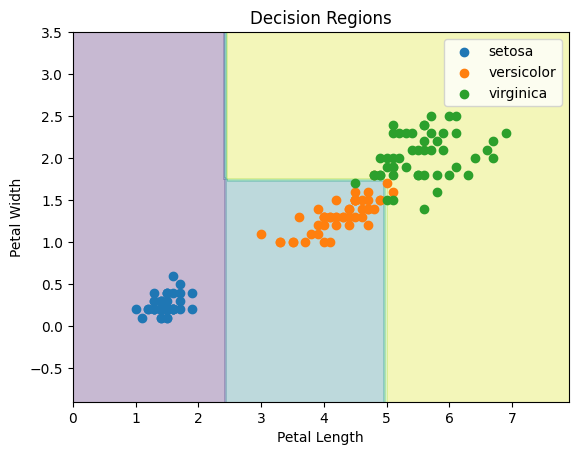

In [19]:
tree = build_tree(X_vis, y, max_depth=3)
plot_decision_boundary(X_vis, y, tree)